## 留意事項
* 本資料は教育・情報提供を目的としたものであり、特定の暗号資産・金融商品の売買、投資行動を推奨または勧誘するものではありません。
* 本資料に含まれる見解、分析、シミュレーション等は作成時点の情報および過去データ等に基づくものであり、その正確性・完全性を保証するものではありません。また、将来の成果・価格動向・収益等を保証するものではありません。
* 外部サービス名・製品名の記載は例示であり、主催者またはビットバンク株式会社による推奨、提携、保証を意味するものではありません。

# 先物乖離 Part 2-2: コストを考慮した検証

**日程**: 2026年3月12日 20:00〜21:00  
**前回**: Part 2-1（3/12） アルトコイン362銘柄でのZ-Score逆張り検証  
**今回**: コスト（手数料・スリッページ）考慮した検証  

### 前回のおさらい
- 362銘柄中229銘柄（63%）でSharpe > 0 → **ただしコスト前の話**
- 出来高が大きい銘柄ほどパフォーマンスが良い傾向
- 極端な乖離時の反転率は約37%

### 今回の問い
**取引には毎回手数料がかかる。それを引いたら、まだ利益は残るのか？**

### 今回やること
1. 取引手数料の基本を理解する
2. Part 2-1 と同じ362銘柄で「コスト込み」バックテストを実行
3. コスト前 vs コスト後でどれだけ結果が変わるか比較
4. 売買回転率（ターンオーバー）とコスト負担の関係を分析
5. コスト後も生き残る銘柄の特徴を探る

---
## 環境設定

In [5]:
%pip install japanize-matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# sys は Python の標準ライブラリで、Python インタープリタ自体の情報や設定を操作するモジュール
# このコードで使われている sys.path は、モジュールの検索パスリスト
# Python が import するとき、このリストの順番にフォルダを探しにいく
# sys.path = [
#     ".",          # ← これを先頭に追加（カレントディレクトリ）
#     "/usr/lib/python3",
#     ...
# ]
# .insert(0, ".") で「まずカレントディレクトリを探す」を先頭に追加している。
# Jupyter Notebook では作業ディレクトリが自動で path に入らないことがあるため、
# 同じフォルダにある自作モジュールを import できるようにするための定型文として書かれている
import sys

sys.path.insert(0, ".")

import warnings

warnings.simplefilter("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

try:
    import japanize_matplotlib
except ImportError:
    pass

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)
print("準備完了")

準備完了


---
## 取引手数料の基本

取引所で売買するたびに「手数料」がかかります。

| 用語 | 意味 |
|------|------|
| **Taker手数料** | 成行注文（すぐ約定）にかかる手数料。今回はこちらを使用 |
| **Maker手数料** | 指値注文（板に並べる）にかかる手数料。Takerより安い |
| **片道** | エントリーまたは決済の1回分 |
| **往復** | エントリー＋決済の合計 |

**今回の前提**
- Binance Taker手数料: **0.04%**（片道）
- 往復: **0.08%**
- スリッページ: ポジションが小口（$100想定）のため無視
- ファンディングレート: 今回は省略

In [7]:
taker_fee = 0.0004  # 0.04%
position_usd = 100

entry_cost = position_usd * taker_fee
exit_cost = position_usd * taker_fee
round_trip = entry_cost + exit_cost

print("=" * 60)
print("手数料の計算例")
print("=" * 60)
print()
print(f"  Taker手数料率     : {taker_fee*100:.2f}%")
print(f"  ポジションサイズ  : ${position_usd}")
print(f"  エントリー手数料  : ${entry_cost:.4f}")
print(f"  決済手数料        : ${exit_cost:.4f}")
print(f"  往復合計          : ${round_trip:.4f}")
print()
print("  ポイント:")
print("  → $100で1往復すると$0.08の手数料")
print()
days = 365
annual_cost = round_trip * days
print(f"  仮に毎日ポジション反転した場合:")
print(f"  年間手数料        : ${annual_cost:.2f}")
print(f"  対ポジション比    : {annual_cost/position_usd*100:.1f}%")
print()
print("  → 年間29.2%のリターンがないと手数料負け")
print("  → だから『コスト前は儲かる』は当てにならない！")

手数料の計算例

  Taker手数料率     : 0.04%
  ポジションサイズ  : $100
  エントリー手数料  : $0.0400
  決済手数料        : $0.0400
  往復合計          : $0.0800

  ポイント:
  → $100で1往復すると$0.08の手数料

  仮に毎日ポジション反転した場合:
  年間手数料        : $29.20
  対ポジション比    : 29.2%

  → 年間29.2%のリターンがないと手数料負け
  → だから『コスト前は儲かる』は当てにならない！


---
## コスト付きバックテスト結果の読み込み

Part 2-1 と同じデータ・同じ戦略に手数料を入れた**事前計算済みCSV**を読み込みます。  
このセクションでは、以降の分析に使う集計結果とPnL時系列を準備します。

**コスト計算のロジック（計算済み）**
```
毎日のシグナル: Z-Score > 0 → ショート、Z-Score < 0 → ロング
シグナルが前日と同じ → ポジション維持 → コストゼロ
シグナルが前日から変化 → 売買発生 → 手数料発生
```


In [9]:
from pathlib import Path

TAKER_FEE = 0.0004
TOP_N_PNL = 10


def find_csv_dir(required_files):
    candidates = [
        Path("."),
        Path("../csv"),
        Path("./csv"),
        Path("./results"),
        Path("results"),
    ]
    for d in candidates:
        if all((d / f).exists() for f in required_files):
            return d
    missing = ", ".join(required_files)
    raise FileNotFoundError(
        "必要CSVが見つかりません。"
        f"\n必要: {missing}"
        "\n探索先: ../csv, ./csv, ./results, results"
    )


CSV_DIR = find_csv_dir(
    [
        "altcoin_basis_cost_backtest.csv",
        "altcoin_basis_cost_pnl_top10.csv",
    ]
)

print(f"CSV読み込み先: {CSV_DIR}")

CSV読み込み先: .


In [10]:
print("CSVデータ読み込み中...")

df = pd.read_csv(CSV_DIR / "altcoin_basis_cost_backtest.csv")
df = df.sort_values("sharpe_net", ascending=False).reset_index(drop=True)

pnl_long = pd.read_csv(
    CSV_DIR / "altcoin_basis_cost_pnl_top10.csv",
    parse_dates=["date"],
)

required_cols = {"date", "symbol", "pnl_gross", "pnl_net"}
missing_cols = required_cols - set(pnl_long.columns)
if missing_cols:
    raise ValueError(f"altcoin_basis_cost_pnl_top10.csv の列不足: {sorted(missing_cols)}")

pnl_curves = {}
for sym, sub in pnl_long.groupby("symbol"):
    tmp = sub.sort_values("date").set_index("date")
    pnl_curves[sym] = tmp[["pnl_gross", "pnl_net"]].copy()

print(f"  読み込み完了: {len(df)}銘柄")
print(f"  PnL曲線対象  : {len(pnl_curves)}銘柄")
print(f"  手数料(表示) : Taker {TAKER_FEE*100:.2f}% / 片道")

CSVデータ読み込み中...
  読み込み完了: 362銘柄
  PnL曲線対象  : 10銘柄
  手数料(表示) : Taker 0.04% / 片道


必要CSVの読み込みが完了しました。次に、コスト前後で全体統計がどう変わるかを確認します。


---
## コスト前 vs コスト後: 全体統計

まずは全体統計を比較し、コスト前後の変化量を確認します。


In [11]:
display(df)

,symbol,data_days,avg_volume_usd,sharpe_gross,sharpe_net,return_gross,return_net,win_gross,win_net,dd_gross,dd_net,n_trades,turnover_pct,total_cost
0,KMNO,291,2.914197e+06,3.438902,3.308575,2.883003,2.772203,56.701031,56.701031,-0.298846,-0.304446,139,47.766323,0.1108
1,MORPHO,141,1.398087e+07,3.287524,3.157181,1.218322,1.169922,58.865248,57.446809,-0.307484,-0.312284,61,43.262411,0.0484
2,SYRUP,290,1.396510e+07,3.001005,2.857664,2.501398,2.381798,55.862069,55.517241,-0.419390,-0.431390,150,51.724138,0.1196
3,BARD,156,1.486378e+07,2.906385,2.855830,1.516633,1.488233,55.128205,55.128205,-0.220376,-0.221976,36,23.076923,0.0284
4,NIL,334,5.178618e+06,2.920186,2.813636,3.482017,3.355217,55.389222,55.089820,-0.613557,-0.629557,159,47.604790,0.1268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,YB,129,6.675134e+06,-1.955193,-2.067912,-0.883293,-0.934893,44.961240,44.961240,-0.858133,-0.886933,65,50.387597,0.0516
358,ALLO,102,1.116023e+07,-2.071122,-2.167485,-0.786334,-0.823534,43.137255,43.137255,-0.981335,-1.017335,47,46.078431,0.0372
359,FORM,339,1.177156e+07,-2.220039,-2.282589,-2.881603,-2.964403,45.132743,45.132743,-3.756023,-3.828823,104,30.678466,0.0828
360,SAPIEN,107,7.021013e+06,-2.354764,-2.425633,-1.208333,-1.244733,46.728972,45.794393,-1.537188,-1.561188,46,42.990654,0.0364


In [12]:
print("=" * 60)
print("コスト前 vs コスト後の全体統計")
print("=" * 60)
print()
# gross（グロス） = コスト差し引き前の数値、net（ネット） = コスト差し引き後の数値
# 英語の重さの単位からきている
# gross（グロス） = 「総重量」梱包材や容器も含めた重さ全体
# net（ネット） = 「正味重量」中身だけの重さ（網 = net で包んだ中身）
# スーパーの食品ラベルに「内容量」と書いてあるのが net、パッケージごとの重さが gross と同じ概念
for label, sc, rc in [
    ("コスト前", "sharpe_gross", "return_gross"),
    ("コスト後", "sharpe_net", "return_net"),
]:
    n_pos = (df[sc] > 0).sum()
    pct = n_pos / len(df) * 100
    print(f"  【{label}】")
    print(f"    Sharpe > 0        : {n_pos} / {len(df)} ({pct:.1f}%)")
    print(f"    Sharpe 平均       : {df[sc].mean():+.3f}")
    print(f"    Sharpe 中央値     : {df[sc].median():+.3f}")
    print(f"    累積リターン > 0  : {(df[rc] > 0).sum()} ({(df[rc] > 0).mean()*100:.1f}%)")
    print()

df["sharpe_drop"] = df["sharpe_gross"] - df["sharpe_net"]
print(f"  【コストの影響】")
print(f"    Sharpe低下 平均   : {df['sharpe_drop'].mean():.3f}")
print(f"    Sharpe低下 中央値 : {df['sharpe_drop'].median():.3f}")
print(f"    売買回転率 平均   : {df['turnover_pct'].mean():.1f}%")

コスト前 vs コスト後の全体統計

  【コスト前】
    Sharpe > 0        : 226 / 362 (62.4%)
    Sharpe 平均       : +0.213
    Sharpe 中央値     : +0.189
    累積リターン > 0  : 226 (62.4%)

  【コスト後】
    Sharpe > 0        : 199 / 362 (55.0%)
    Sharpe 平均       : +0.104
    Sharpe 中央値     : +0.088
    累積リターン > 0  : 199 (55.0%)

  【コストの影響】
    Sharpe低下 平均   : 0.109
    Sharpe低下 中央値 : 0.107
    売買回転率 平均   : 42.9%


コスト後はSharpeと累積リターンが全体に低下する傾向を確認できました。次に分布の形を比較します。


---
## Sharpeレシオの分布比較

Sharpeレシオの分布を並べて、コストで分布がどちらにシフトするかを確認します。


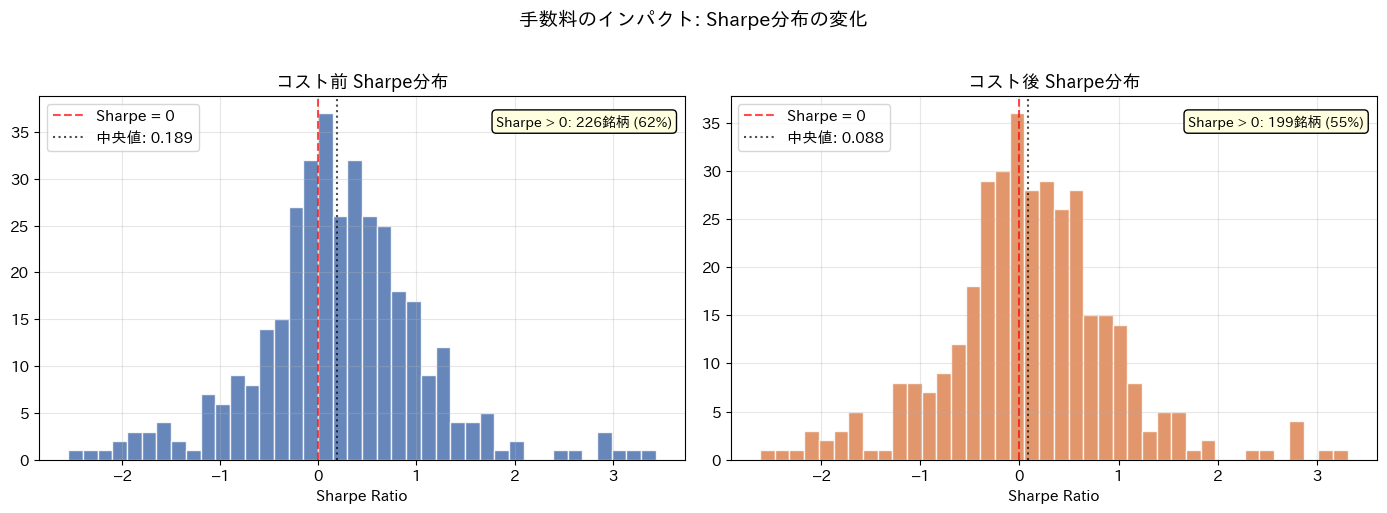

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in [
    (axes[0], "sharpe_gross", "コスト前 Sharpe分布", "#4C72B0"),
    (axes[1], "sharpe_net", "コスト後 Sharpe分布", "#DD8452"),
]:
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7, label="Sharpe = 0")
    ax.axvline(
        df[col].median(),
        color="black",
        linestyle=":",
        alpha=0.7,
        label=f"中央値: {df[col].median():.3f}",
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sharpe Ratio")
    ax.legend()
    n_pos = (df[col] > 0).sum()
    ax.text(
        0.98,
        0.95,
        f"Sharpe > 0: {n_pos}銘柄 ({n_pos/len(df)*100:.0f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"),
    )

plt.suptitle("手数料のインパクト: Sharpe分布の変化", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

分布は全体に左側へ寄り、コストで優位性が削られる銘柄が増える傾向が見られました。次に銘柄別ランキングを確認します。


---
## コスト後 TOP 20 / WORST 10 ランキング

コスト後のランキングを確認し、残る銘柄と悪化する銘柄を把握します。


In [14]:
print("=" * 70)
print("コスト後 TOP 20（Sharpe Net 順）")
print("=" * 70)
for i, (_, row) in enumerate(df.head(20).iterrows()):
    print(
        f"  {i+1:>2}. {row['symbol']:<10s}  "
        f"Sharpe: {row['sharpe_gross']:+.2f} → {row['sharpe_net']:+.2f}  "
        f"Return: {row['return_net']:+.3f}  "
        f"回転率: {row['turnover_pct']:.0f}%  "
        f"Vol: ${row['avg_volume_usd']/1e6:.1f}M"
    )

print()
print("=" * 70)
print("コスト後 WORST 10")
print("=" * 70)
for _, row in df.tail(10).iterrows():
    print(
        f"  {row['symbol']:<10s}  " f"Sharpe: {row['sharpe_gross']:+.2f} → {row['sharpe_net']:+.2f}"
    )

コスト後 TOP 20（Sharpe Net 順）
   1. KMNO        Sharpe: +3.44 → +3.31  Return: +2.772  回転率: 48%  Vol: $2.9M
   2. MORPHO      Sharpe: +3.29 → +3.16  Return: +1.170  回転率: 43%  Vol: $14.0M
   3. SYRUP       Sharpe: +3.00 → +2.86  Return: +2.382  回転率: 52%  Vol: $14.0M
   4. BARD        Sharpe: +2.91 → +2.86  Return: +1.488  回転率: 23%  Vol: $14.9M
   5. NIL         Sharpe: +2.92 → +2.81  Return: +3.355  回転率: 48%  Vol: $5.2M
   6. TRUMP       Sharpe: +2.91 → +2.78  Return: +3.357  回転率: 51%  Vol: $154.4M
   7. VELODROME   Sharpe: +2.67 → +2.55  Return: +3.380  回転率: 44%  Vol: $3.8M
   8. PUMP        Sharpe: +2.41 → +2.32  Return: +1.470  回転率: 40%  Vol: $54.3M
   9. ERA         Sharpe: +2.04 → +1.94  Return: +1.130  回転率: 36%  Vol: $24.3M
  10. NEWT        Sharpe: +2.00 → +1.88  Return: +1.334  回転率: 43%  Vol: $7.5M
  11. SYN         Sharpe: +1.89 → +1.81  Return: +3.945  回転率: 42%  Vol: $3.0M
  12. KITE        Sharpe: +1.73 → +1.66  Return: +0.691  回転率: 35%  Vol: $20.4M
  13. FF          Sharpe: +1.7

コスト後も上位を維持する銘柄がある一方で、下位はさらに悪化する傾向を確認できました。次に上位銘柄の前後差を可視化します。


---
## TOP 20 の Sharpe を棒グラフで比較

上位20銘柄について、コスト前後のSharpe差を横並びで比較します。


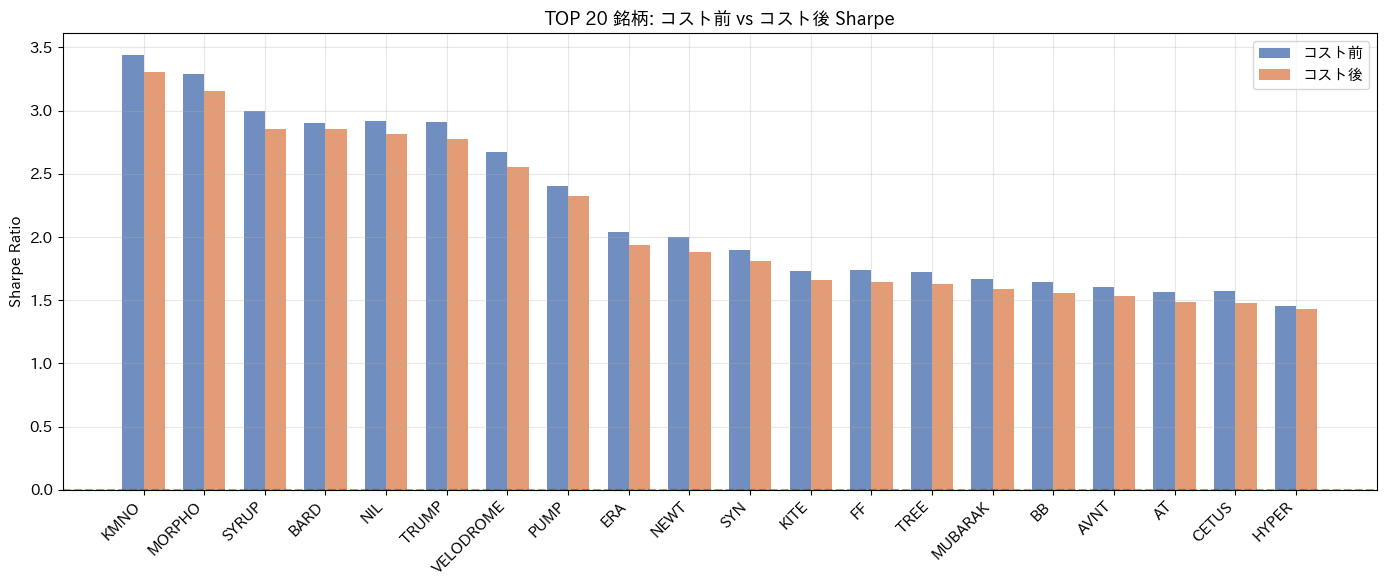

In [15]:
top20 = df.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(top20))
w = 0.35

ax.bar(
    [i - w / 2 for i in x], top20["sharpe_gross"], w, label="コスト前", color="#4C72B0", alpha=0.8
)
ax.bar([i + w / 2 for i in x], top20["sharpe_net"], w, label="コスト後", color="#DD8452", alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(top20["symbol"], rotation=45, ha="right")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("TOP 20 銘柄: コスト前 vs コスト後 Sharpe", fontsize=13)
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

低下幅には銘柄差があり、コスト耐性の違いを確認できました。次に回転率との関係を確認します。


---
## 売買回転率（ターンオーバー）の分析

**売買回転率** = 全取引日のうち、何%の日でポジション変更（売買）が発生したか

- 回転率 50% → 2日に1回売買 → コスト少なめ
- 回転率 80% → ほぼ毎日売買 → コスト大きい

このセクションでは、回転率とコスト負担（Sharpe低下幅）の関係を確認します。


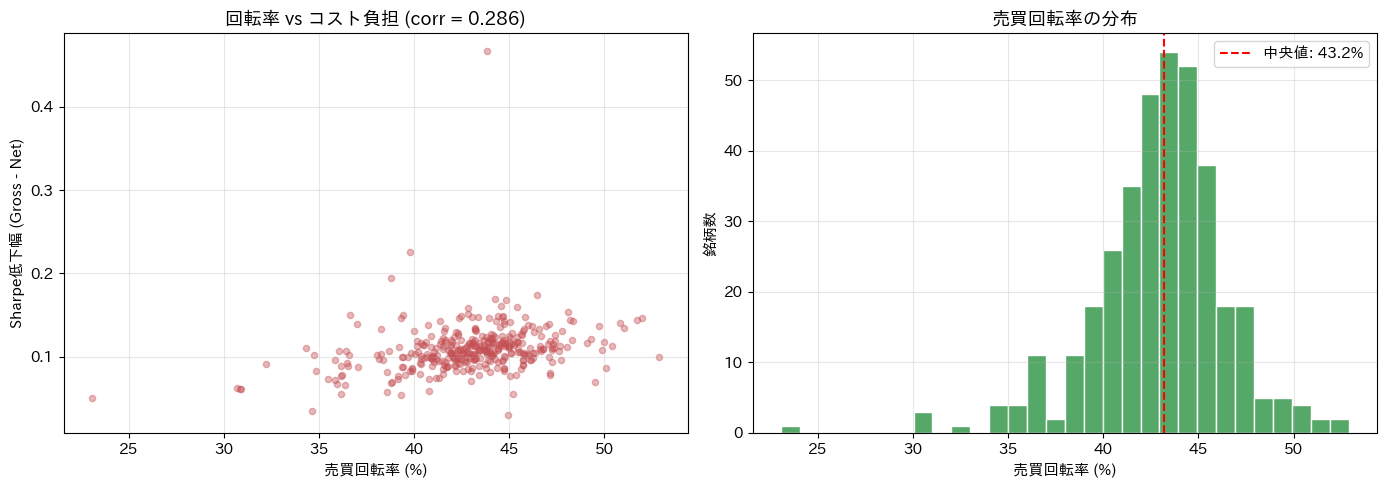

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df["turnover_pct"], df["sharpe_drop"], alpha=0.4, s=20, c="#C44E52")
ax.set_xlabel("売買回転率 (%)")
ax.set_ylabel("Sharpe低下幅 (Gross - Net)")
corr = df["turnover_pct"].corr(df["sharpe_drop"])
ax.set_title(f"回転率 vs コスト負担 (corr = {corr:.3f})")

ax = axes[1]
ax.hist(df["turnover_pct"], bins=30, color="#55A868", edgecolor="white")
ax.set_xlabel("売買回転率 (%)")
ax.set_ylabel("銘柄数")
ax.set_title("売買回転率の分布")
ax.axvline(
    df["turnover_pct"].median(),
    color="red",
    linestyle="--",
    label=f"中央値: {df['turnover_pct'].median():.1f}%",
)
ax.legend()

plt.tight_layout()
plt.show()

回転率が高いほどコスト負担が増えやすい傾向を確認できました。次に全銘柄の散布図で俯瞰します。


---
## コスト前 vs コスト後 Sharpe 散布図

全銘柄を散布図で比較し、コスト影響の広がりを確認します。


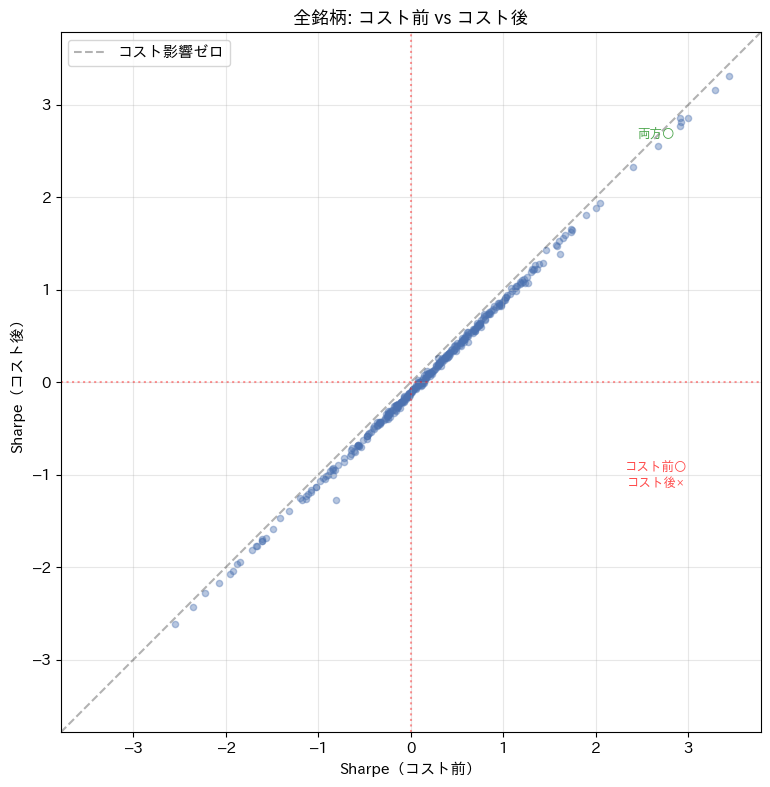

  コスト前もコスト後もSharpe > 0 : 199銘柄
  コスト前はプラスだがコスト後マイナス : 27銘柄 ← コストに負けた


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df["sharpe_gross"], df["sharpe_net"], alpha=0.4, s=20, c="#4C72B0")

# グラフの範囲を両軸で同じにする
lim = max(abs(df["sharpe_gross"]).max(), abs(df["sharpe_net"]).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3, label="コスト影響ゼロ")
ax.axhline(0, color="red", linestyle=":", alpha=0.4)
ax.axvline(0, color="red", linestyle=":", alpha=0.4)

ax.set_xlabel("Sharpe（コスト前）")
ax.set_ylabel("Sharpe（コスト後）")
ax.set_title("全銘柄: コスト前 vs コスト後", fontsize=13)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.legend()

ax.text(
    lim * 0.7, -lim * 0.3, "コスト前○\nコスト後×", ha="center", fontsize=9, color="red", alpha=0.7
)
ax.text(lim * 0.7, lim * 0.7, "両方○", ha="center", fontsize=9, color="green", alpha=0.7)

plt.tight_layout()
plt.show()

both_pos = ((df["sharpe_gross"] > 0) & (df["sharpe_net"] > 0)).sum()
gross_only = ((df["sharpe_gross"] > 0) & (df["sharpe_net"] <= 0)).sum()
print(f"  コスト前もコスト後もSharpe > 0 : {both_pos}銘柄")
print(f"  コスト前はプラスだがコスト後マイナス : {gross_only}銘柄 ← コストに負けた")

多くの銘柄が対角線より下側に位置し、コスト影響が広範囲に及ぶことを確認できました。次にTOP銘柄のPnL曲線を確認します。


---
## TOP銘柄のPnL曲線: コスト前 vs コスト後

TOP銘柄の累積PnLを時系列で比較し、コストでどれだけ利益が削られるかを確認します。


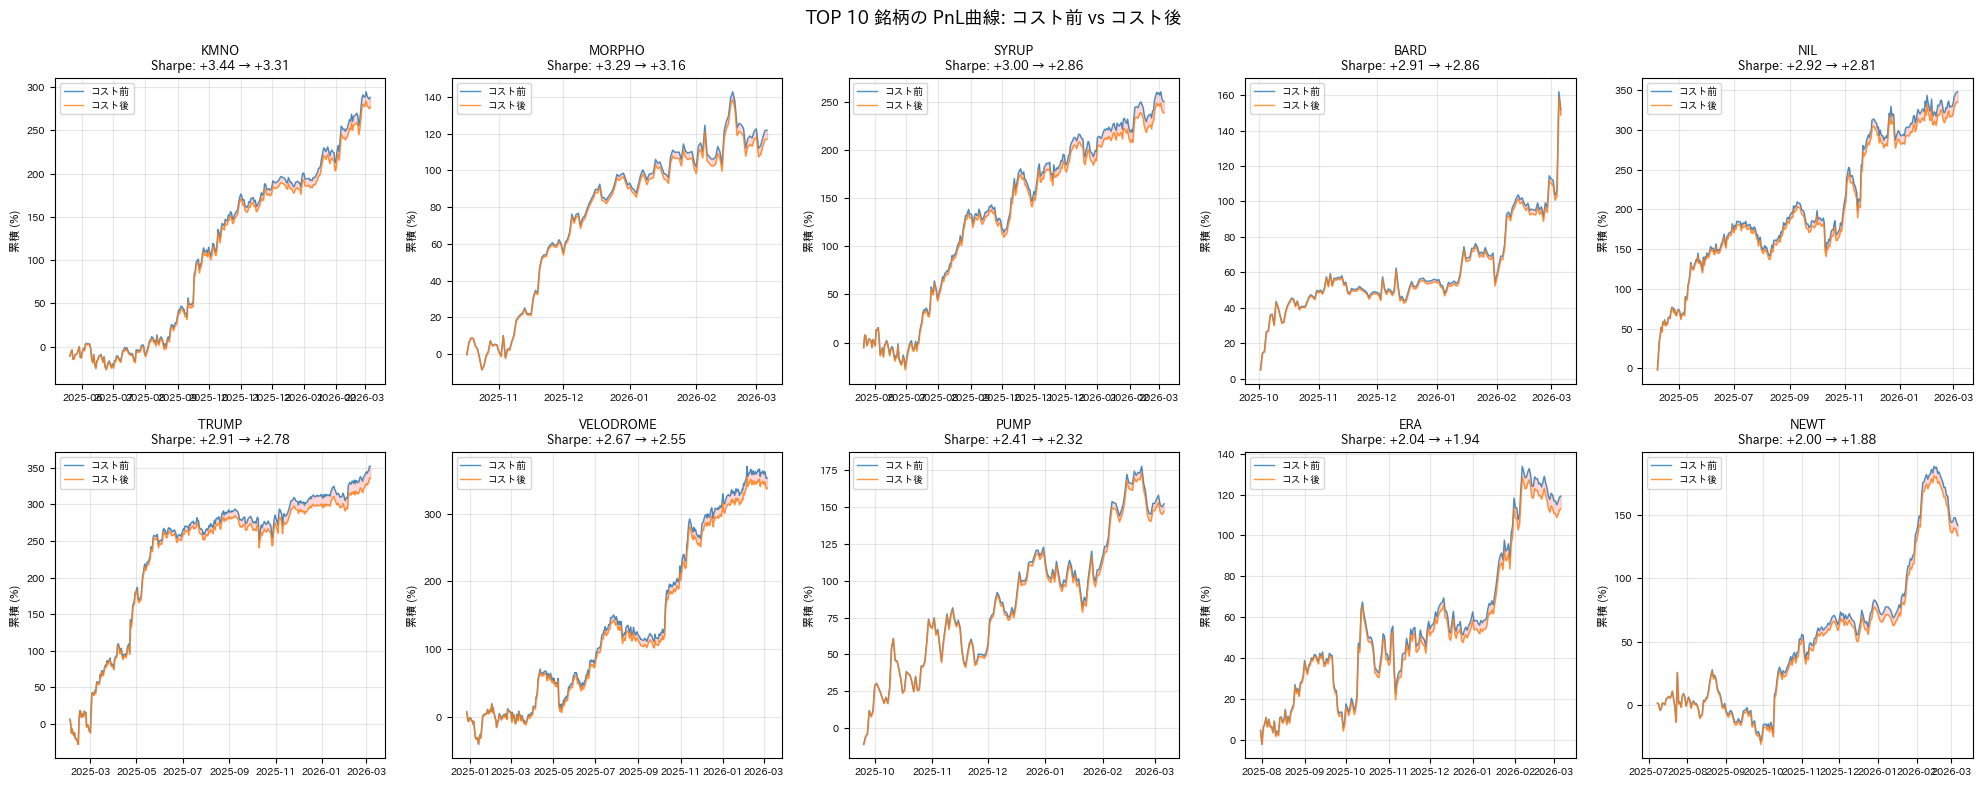

In [ ]:
top_symbols = df.head(TOP_N_PNL)["symbol"].tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
# flatten()は多次元配列を1次元に変換する
# axes の形: (2, 5) の2次元配列 [[ax0, ax1, ax2, ax3, ax4],[ax5, ax6, ax7, ax8, ax9]]
# axes_flat の形: (10,) の1次元配列 [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
# こうすることで、for文で回しやすくなる
axes_flat = axes.flatten()

for i, sym in enumerate(top_symbols):
    if sym not in pnl_curves:
        continue
    ax = axes_flat[i]
    pnl = pnl_curves[sym]
    cum_g = pnl["pnl_gross"].cumsum() * 100
    cum_n = pnl["pnl_net"].cumsum() * 100

    ax.plot(cum_g.index, cum_g, label="コスト前", alpha=0.8, linewidth=1)
    ax.plot(cum_n.index, cum_n, label="コスト後", alpha=0.8, linewidth=1)
    ax.fill_between(cum_n.index, cum_g, cum_n, alpha=0.15, color="red")

    # そのシンボルの一行目（おそらくシンボル名なので1行だけだと思うが）
    # ilocをdfに使うとSeries、Seriesに使うと要素が指定できる
    row = df[df["symbol"] == sym].iloc[0]
    ax.set_title(
        f"{sym}\nSharpe: {row['sharpe_gross']:+.2f} → {row['sharpe_net']:+.2f}", fontsize=9
    )
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("累積 (%)", fontsize=8)

plt.suptitle(f"TOP {TOP_N_PNL} 銘柄の PnL曲線: コスト前 vs コスト後", fontsize=13)
plt.tight_layout()
plt.show()

コスト後の曲線は全体に下方シフトし、銘柄ごとの削られ方の差も確認できました。次に生存銘柄の特徴を比較します。


---
## コスト後も生き残る銘柄の特徴

コスト後に生き残る銘柄と脱落する銘柄の特徴差を比較します。


コスト後も生き残る銘柄 vs コスト負けした銘柄

  【生存組】 199銘柄
    回転率 平均       : 43.1%
    出来高 平均       : $46.7M
    Sharpe(前) 平均   : +0.781
    データ日数 平均   : 895日

  【脱落組】 27銘柄
    回転率 平均       : 43.3%
    出来高 平均       : $17.5M
    Sharpe(前) 平均   : +0.064
    データ日数 平均   : 1178日



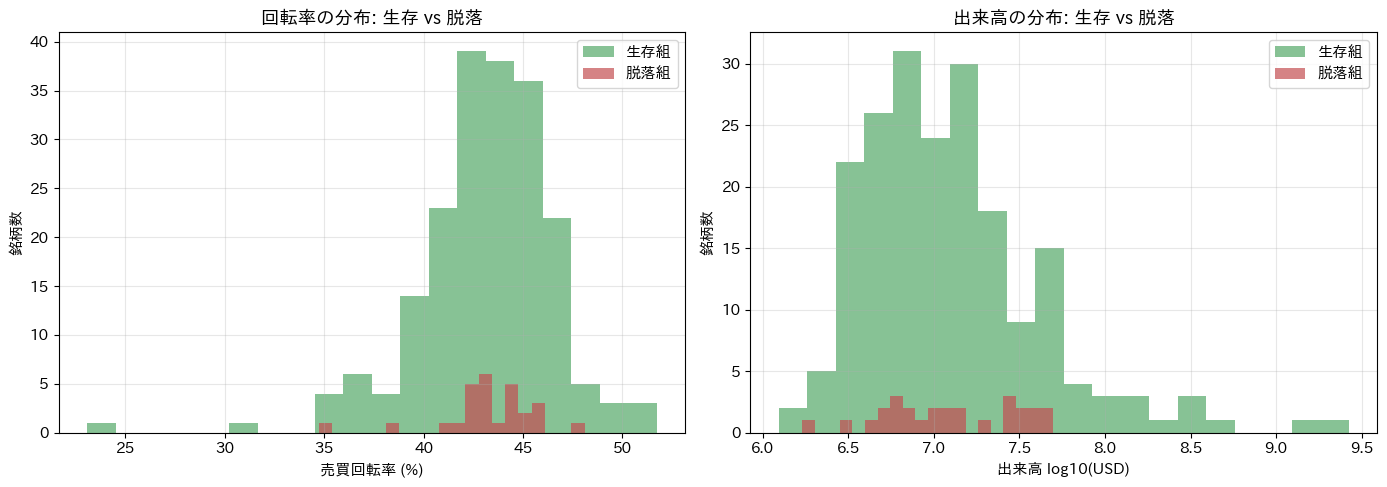

In [28]:
survivors = df[df["sharpe_net"] > 0]
killed = df[(df["sharpe_gross"] > 0) & (df["sharpe_net"] <= 0)]

print("=" * 60)
print("コスト後も生き残る銘柄 vs コスト負けした銘柄")
print("=" * 60)
print()

if len(survivors) > 0 and len(killed) > 0:
    for label, grp in [("生存組", survivors), ("脱落組", killed)]:
        print(f"  【{label}】 {len(grp)}銘柄")
        print(f"    回転率 平均       : {grp['turnover_pct'].mean():.1f}%")
        print(f"    出来高 平均       : ${grp['avg_volume_usd'].mean()/1e6:.1f}M")
        print(f"    Sharpe(前) 平均   : {grp['sharpe_gross'].mean():+.3f}")
        print(f"    データ日数 平均   : {grp['data_days'].mean():.0f}日")
        print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(survivors["turnover_pct"], bins=20, alpha=0.7, label="生存組", color="#55A868")
ax.hist(killed["turnover_pct"], bins=20, alpha=0.7, label="脱落組", color="#C44E52")
ax.set_xlabel("売買回転率 (%)")
ax.set_ylabel("銘柄数")
ax.set_title("回転率の分布: 生存 vs 脱落")
ax.legend()

ax = axes[1]
ax.hist(
    np.log10(survivors["avg_volume_usd"].clip(lower=1)),
    bins=20,
    alpha=0.7,
    label="生存組",
    color="#55A868",
)
ax.hist(
    np.log10(killed["avg_volume_usd"].clip(lower=1)),
    bins=20,
    alpha=0.7,
    label="脱落組",
    color="#C44E52",
)
ax.set_xlabel("出来高 log10(USD)")
ax.set_ylabel("銘柄数")
ax.set_title("出来高の分布: 生存 vs 脱落")
ax.legend()

plt.tight_layout()
plt.show()

生存組と脱落組で、出来高や初期優位性に差がある傾向を確認できました。最後に要点をまとめます。


---
## まとめ

ここまでの分析結果を整理し、実運用で重視すべきポイントを確認します。


In [29]:
gross_pos = (df["sharpe_gross"] > 0).sum()
net_pos = (df["sharpe_net"] > 0).sum()
both_pos = ((df["sharpe_gross"] > 0) & (df["sharpe_net"] > 0)).sum()
killed_n = gross_pos - both_pos

survivors = df[df["sharpe_net"] > 0]
killed = df[(df["sharpe_gross"] > 0) & (df["sharpe_net"] <= 0)]

print("=" * 60)
print("先物乖離 Part 2-2: コスト分析まとめ")
print("=" * 60)
print()
print(f"1. コスト前 → コスト後の変化")
print(f"   - Sharpe > 0: {gross_pos} → {net_pos} （{killed_n}銘柄がコスト負け）")
print(f"   - Sharpe平均: {df['sharpe_gross'].mean():+.3f} → {df['sharpe_net'].mean():+.3f}")
print(f"   - Sharpe中央値: {df['sharpe_gross'].median():+.3f} → {df['sharpe_net'].median():+.3f}")
print()
print(f"2. コストの内訳")
print(f"   - 手数料: Taker {TAKER_FEE*100:.2f}% / 片道")
print(f"   - 平均回転率: {df['turnover_pct'].mean():.1f}%")
print(f"   - スリッページ: 小口（$100）のため無視")
print()
print(f"3. コスト後も有望な銘柄の傾向")
if len(survivors) > 0 and len(killed) > 0:
    print(f"   - 生存組の回転率: {survivors['turnover_pct'].mean():.1f}%")
    print(f"   - 脱落組の回転率: {killed['turnover_pct'].mean():.1f}%")
    print(f"   - 生存組の出来高: ${survivors['avg_volume_usd'].mean()/1e6:.1f}M")
    print(f"   - 脱落組の出来高: ${killed['avg_volume_usd'].mean()/1e6:.1f}M")
print()
print(f"4. 教訓")
print(f"   - バックテストでは必ずコストを入れること")
print(f"   - 回転率が低い（シグナルが安定している）銘柄ほどコスト効率が良い")
print(f"   - 『コスト前Sharpe高い = 良い戦略』ではない")
print()
print(f"5. 次のステップ")
print(f"   - Part 2-3: 時間足での精緻化（1h足でエントリー/決済タイミングを改善）")

先物乖離 Part 2-2: コスト分析まとめ

1. コスト前 → コスト後の変化
   - Sharpe > 0: 226 → 199 （27銘柄がコスト負け）
   - Sharpe平均: +0.213 → +0.104
   - Sharpe中央値: +0.189 → +0.088

2. コストの内訳
   - 手数料: Taker 0.04% / 片道
   - 平均回転率: 42.9%
   - スリッページ: 小口（$100）のため無視

3. コスト後も有望な銘柄の傾向
   - 生存組の回転率: 43.1%
   - 脱落組の回転率: 43.3%
   - 生存組の出来高: $46.7M
   - 脱落組の出来高: $17.5M

4. 教訓
   - バックテストでは必ずコストを入れること
   - 回転率が低い（シグナルが安定している）銘柄ほどコスト効率が良い
   - 『コスト前Sharpe高い = 良い戦略』ではない

5. 次のステップ
   - Part 2-3: 時間足での精緻化（1h足でエントリー/決済タイミングを改善）


コスト前提での評価が重要であり、回転率とコスト耐性の確認が必須であることを整理できました。


## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。